# Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami pola, distribusi, hubungan antar variabel, serta karakteristik data sebelum tahap preprocessing dan modeling. Setiap analisis pada notebook ini memiliki **tujuan** yang jelas dan ditutup dengan **insight** yang dicari, sehingga analisis terarah pada sasaran bisnis: memahami dan memprediksi penjualan.

# 1. Import Library

In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro
import scipy.stats as stats

sns.set_style('whitegrid')

# 2. Load Dataset

In [30]:
# membaca dataset hasil wrangling
df = pd.read_csv('../data/wrangled_data.csv')

# hapus kolom store (tidak dipakai dalam analisis)
df = df.drop(columns=[c for c in ['store', 'store_id'] if c in df.columns])

df.head()

,date,item_id,sales,price,promo,weekday,month
0,2021-01-01,item_1,36,21.3,0,4,1
1,2021-01-02,item_1,36,21.3,0,5,1
2,2021-01-03,item_1,35,21.3,0,6,1
3,2021-01-04,item_1,41,21.3,0,0,1
4,2021-01-05,item_1,53,21.3,0,1,1


# 3. Data Understanding

**Tujuan:** memahami struktur dasar dataset (ukuran, tipe data, kolom) sebelum analisis lebih dalam.

In [31]:
print('Jumlah baris :', df.shape[0])
print('Jumlah kolom :', df.shape[1])

Jumlah baris : 54750
Jumlah kolom : 7


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54750 entries, 0 to 54749
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     54750 non-null  object 
 1   item_id  54750 non-null  object 
 2   sales    54750 non-null  int64  
 3   price    54750 non-null  float64
 4   promo    54750 non-null  int64  
 5   weekday  54750 non-null  int64  
 6   month    54750 non-null  int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 2.9+ MB


In [33]:
df.describe()

,sales,price,promo,weekday,month
count,54750.000000,54750.000000,54750.000000,54750.000000,54750.000000
mean,29.877881,56.077581,0.099233,3.005479,6.526027
std,14.689005,24.102496,0.298977,2.000467,3.447883
min,0.000000,12.200000,0.000000,0.000000,1.000000
25%,19.000000,37.620000,0.000000,1.000000,4.000000
50%,28.000000,58.620000,0.000000,3.000000,7.000000
75%,39.000000,76.300000,0.000000,5.000000,10.000000
max,114.000000,99.990000,1.000000,6.000000,12.000000


# 4. Business Understanding

Pertanyaan bisnis yang akan dijawab melalui EDA:

1. Item apa saja yang paling laku (distribusi penjualan per item)?
2. Produk apa yang penjualannya tertinggi dan terendah?
3. Bagaimana hubungan antara harga produk dan jumlah penjualan?
4. Apakah terdapat pola penjualan berdasarkan waktu (bulan/hari)?
5. Variabel apa yang korelasinya paling kuat terhadap penjualan?
6. Apakah terdapat outlier pada data penjualan, dan apa penyebabnya?

# 5. Pemeriksaan Integritas Data

**Tujuan:** memastikan data layak dianalisis sebagai deret waktu. Jika ada tanggal yang bolong atau nilai mustahil (penjualan negatif, harga ≤ 0), seluruh kesimpulan bisa keliru. Pemeriksaan ini dilakukan **sebelum** menarik insight apa pun.

In [34]:
df['date'] = pd.to_datetime(df['date'])

print('Rentang tanggal :', df['date'].min().date(), '→', df['date'].max().date())
print('Jumlah hari unik:', df['date'].nunique())

rentang_penuh = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
tanggal_hilang = rentang_penuh.difference(df['date'].unique())
print('Tanggal hilang  :', len(tanggal_hilang))

print('Sales negatif   :', (df['sales'] < 0).sum())
print('Harga <= 0      :', (df['price'] <= 0).sum())
print('Duplikat baris  :', df.duplicated().sum())

Rentang tanggal : 2021-01-01 → 2023-12-31
Jumlah hari unik: 1095
Tanggal hilang  : 0
Sales negatif   : 0
Harga <= 0      : 0
Duplikat baris  : 0


**Insight:** memastikan kontinuitas tanggal dan tidak adanya nilai mustahil sebelum lanjut.

# 6. Univariate Analysis

**Catatan:** analisis univariat **tidak dilakukan ke semua kolom**. Kolom pengenal (`item_id`) dan kolom biner (`promo`) tidak relevan dianalisis sebagai distribusi kontinu, sehingga hanya variabel ukuran (**price** dan **sales**) yang dianalisis distribusinya, sedangkan `item_id` dan `promo` dianalisis sebagai frekuensi.

### 6.1 Mendalami Variabel Target (sales)

**Tujuan:** memahami perilaku target sebelum modeling. Jika distribusinya menceng kuat, model regresi umumnya butuh transformasi log.

Skewness sales: 0.812


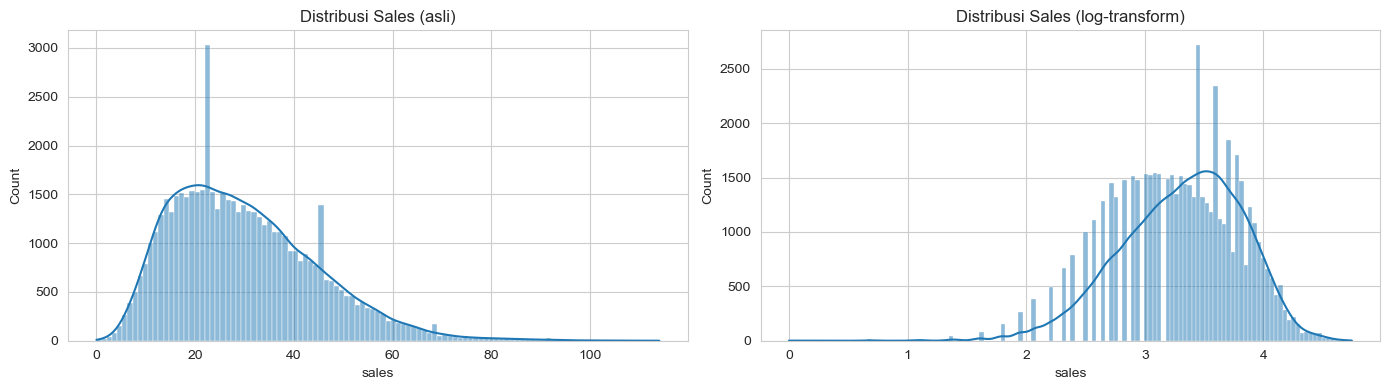

In [35]:
print('Skewness sales:', round(df['sales'].skew(), 3))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['sales'], kde=True, ax=ax[0])
ax[0].set_title('Distribusi Sales (asli)')
sns.histplot(np.log1p(df['sales']), kde=True, ax=ax[1])
ax[1].set_title('Distribusi Sales (log-transform)')
plt.tight_layout()
plt.show()

**Insight:** bila versi log lebih simetris, `np.log1p(sales)` menjadi kandidat target untuk modeling.

### 6.2 Distribusi Fitur Ukuran (price & sales)

**Tujuan:** mengetahui bentuk distribusi variabel ukuran untuk menentukan perlakuan scaling/transformasi. Hanya `price` dan `sales` yang dianalisis karena keduanya variabel kontinu yang bermakna.

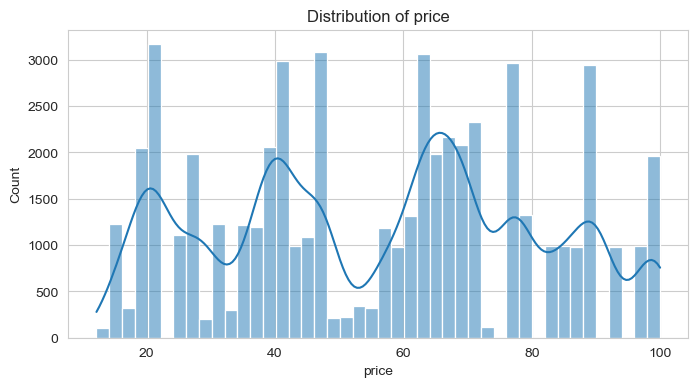

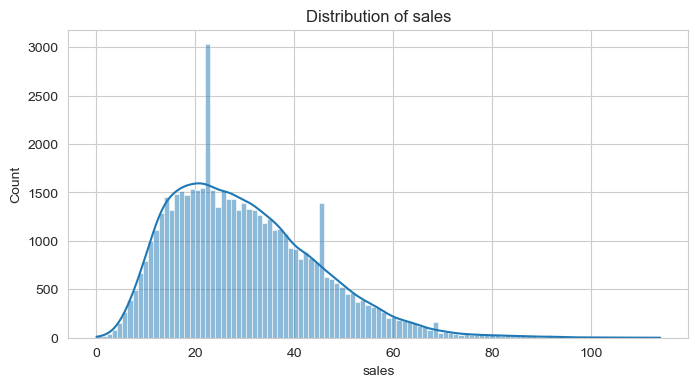

In [36]:
# hanya variabel kontinu yang bermakna
ukur_cols = ['price', 'sales']

for col in ukur_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [37]:
# skewness variabel ukuran
df[ukur_cols].skew().sort_values(ascending=False)

sales    0.812499
price    0.014459
dtype: float64

### 6.3 Frekuensi Fitur Kategorik & Biner

**Tujuan:** melihat sebaran kategori (`item_id`) dan proporsi flag (`promo`) untuk mendeteksi ketidakseimbangan (imbalance).

Proporsi promo:
promo
0    0.901
1    0.099
Name: proportion, dtype: float64


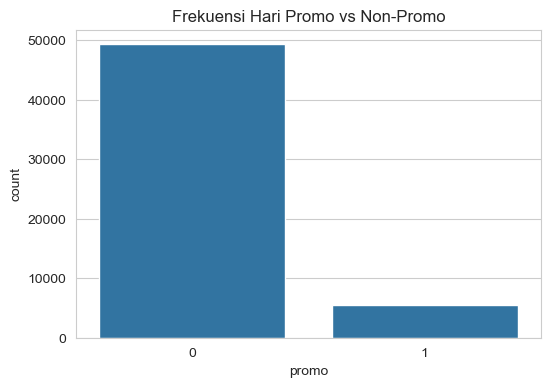

In [38]:
# proporsi promo (0 = tanpa promo, 1 = promo)
if 'promo' in df.columns:
    print('Proporsi promo:')
    print(df['promo'].value_counts(normalize=True).round(3))

    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='promo')
    plt.title('Frekuensi Hari Promo vs Non-Promo')
    plt.show()

In [39]:
# jumlah baris per item (apakah seimbang antar produk?)
print('Jumlah item unik:', df['item_id'].nunique())
df['item_id'].value_counts().describe()

Jumlah item unik: 50


count      50.0
mean     1095.0
std         0.0
min      1095.0
25%      1095.0
50%      1095.0
75%      1095.0
max      1095.0
Name: count, dtype: float64

# 7. Bivariate Analysis

**Tujuan:** mengidentifikasi hubungan antar variabel yang **relevan secara bisnis**. Correlation matrix **tidak menyertakan semua kolom numerik** — kolom seperti `item_id` (pengenal) atau komponen tanggal tidak punya makna korelasi. Maka hanya `price`, `sales`, dan `promo` yang dikorelasikan, karena ketiganya benar-benar saling berhubungan dalam konteks penjualan.

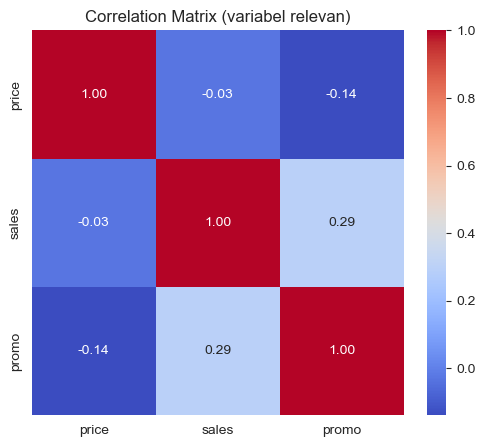

In [40]:
# hanya variabel yang berhubungan secara bisnis
corr_cols = [c for c in ['price', 'sales', 'promo'] if c in df.columns]

plt.figure(figsize=(6, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix (variabel relevan)')
plt.show()

**Insight:** fokus pada hubungan price–sales dan promo–sales yang relevan untuk pengambilan keputusan, tanpa korelasi semu dari variabel pengenal.

# 8. Business Question Analysis

### 8.1 Distribusi Penjualan per Item (Pertanyaan 1)

**Tujuan:** melihat **item mana yang paling laku**. Sumbu-y adalah item dan sumbu-x adalah total penjualan, sehingga langsung terlihat peringkat produk dari yang paling laku hingga paling sepi — informasi yang lebih actionable untuk stok daripada sekadar penjualan per hari.

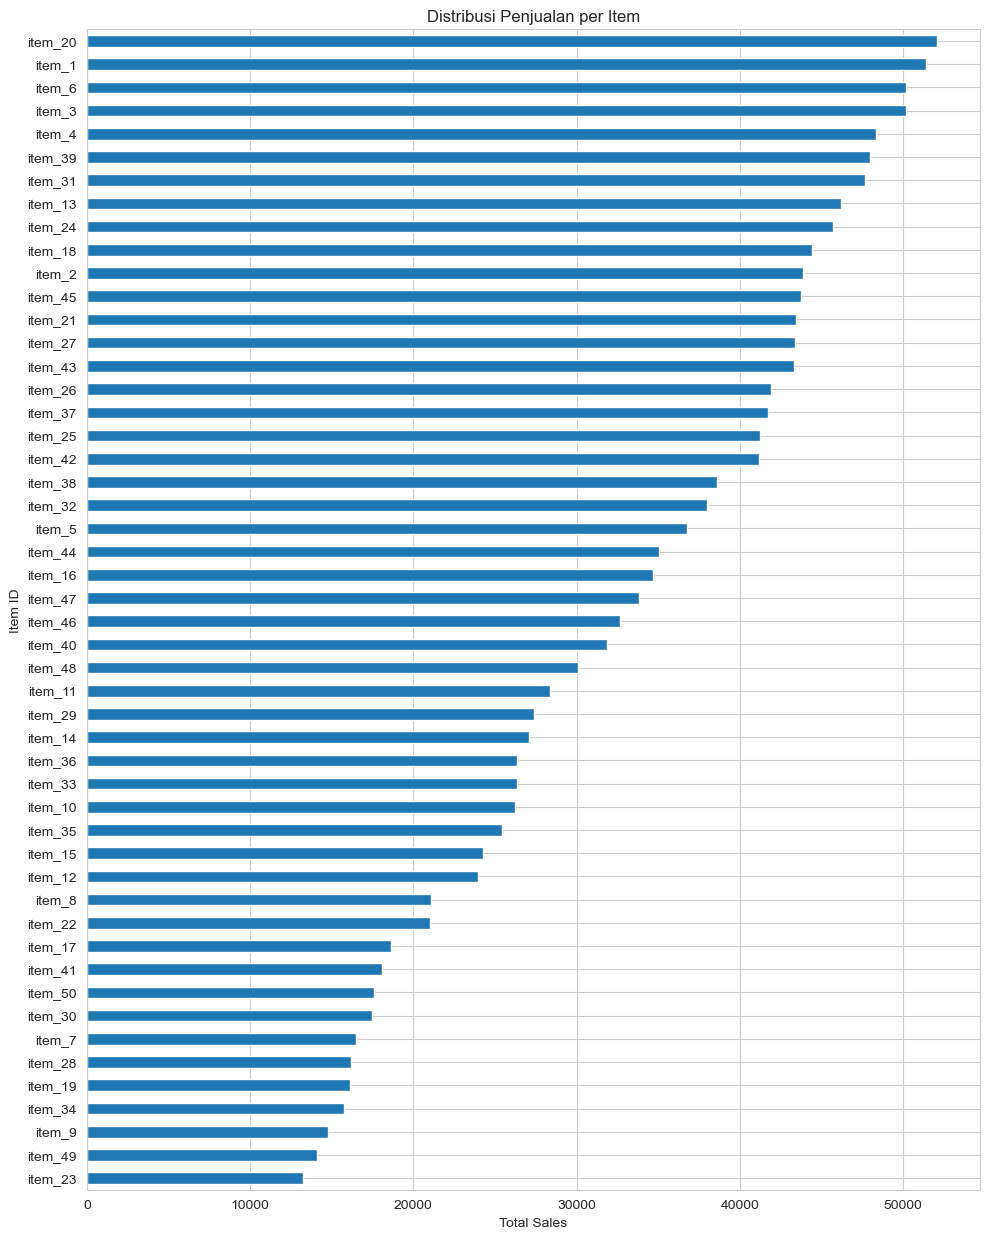

In [41]:
# total penjualan per item, diurutkan
item_sales = df.groupby('item_id')['sales'].sum().sort_values()

plt.figure(figsize=(10, max(6, len(item_sales) * 0.25)))
item_sales.plot(kind='barh')
plt.title('Distribusi Penjualan per Item')
plt.xlabel('Total Sales')
plt.ylabel('Item ID')
plt.tight_layout()
plt.show()

**Insight:** mengidentifikasi item terlaris dan paling sepi sebagai dasar prioritas stok dan promosi.

### 8.2 Produk dengan Penjualan Tertinggi & Terendah (Pertanyaan 2)

**Tujuan:** menyorot 10 produk teratas dan terbawah agar fokus evaluasi lebih tajam.

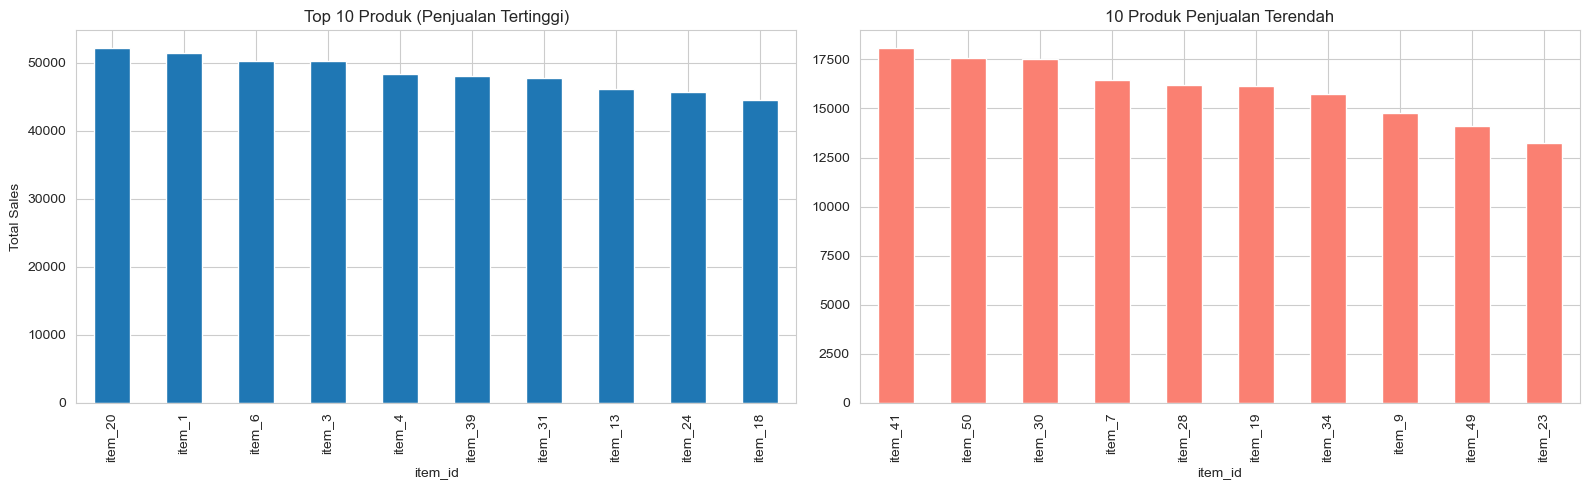

In [42]:
product_sales = df.groupby('item_id')['sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
product_sales.head(10).plot(kind='bar', ax=ax[0])
ax[0].set_title('Top 10 Produk (Penjualan Tertinggi)')
ax[0].set_ylabel('Total Sales')
product_sales.tail(10).plot(kind='bar', ax=ax[1], color='salmon')
ax[1].set_title('10 Produk Penjualan Terendah')
plt.tight_layout()
plt.show()

### 8.2b Tren Penjualan Bulanan per Produk (Grafik Garis)

**Tujuan:** melihat **pergerakan** penjualan tiap produk dari waktu ke waktu, untuk mengetahui apakah produk laris stabil atau hanya melonjak sesaat, dan apakah ada produk yang sedang tumbuh/menurun.

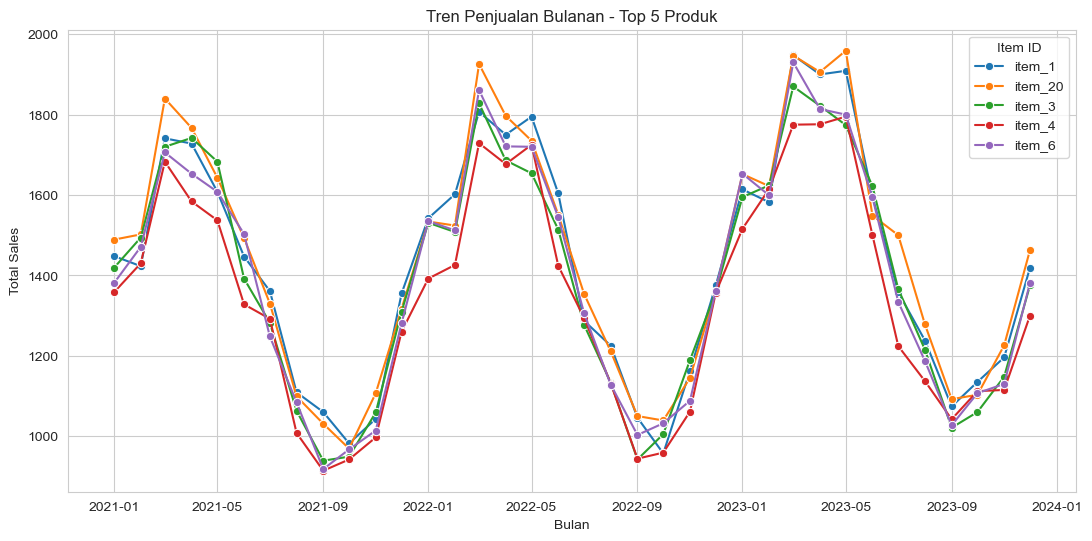

In [43]:
# ambil 5 produk terlaris
top5 = df.groupby('item_id')['sales'].sum().nlargest(5).index

sub = df[df['item_id'].isin(top5)].copy()
sub['ym'] = sub['date'].dt.to_period('M').dt.to_timestamp()
trend_item = sub.groupby(['ym', 'item_id'])['sales'].sum().reset_index()

plt.figure(figsize=(13, 6))
sns.lineplot(data=trend_item, x='ym', y='sales', hue='item_id', marker='o')
plt.title('Tren Penjualan Bulanan - Top 5 Produk')
plt.xlabel('Bulan')
plt.ylabel('Total Sales')
plt.legend(title='Item ID')
plt.show()

**Insight:** membandingkan konsistensi penjualan antarproduk unggulan dan mendeteksi tren naik/turun.

### 8.3 Hubungan Harga dan Penjualan (Pertanyaan 3)

**Tujuan:** menguji apakah harga memengaruhi penjualan. Korelasi agregat saja bisa menyesatkan (Simpson's paradox), maka diuji juga korelasi harga–penjualan **di dalam tiap produk**.

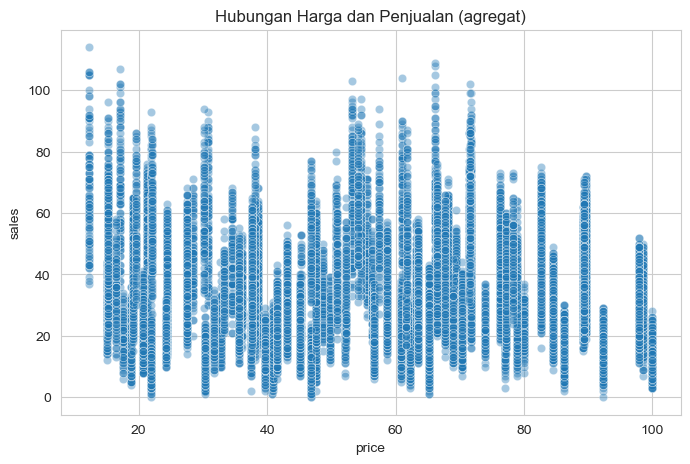

Korelasi harga vs penjualan (agregat): -0.029


In [44]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='price', y='sales', alpha=0.4)
plt.title('Hubungan Harga dan Penjualan (agregat)')
plt.show()

print('Korelasi harga vs penjualan (agregat):',
      round(df['price'].corr(df['sales']), 3))

/var/folders/38/h7rmvkgj03x_t1z_td74_bwm0000gn/T/ipykernel_53247/3777604546.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g['price'].corr(g['sales']))


Rata-rata korelasi harga-penjualan per produk: -0.454

Produk paling sensitif harga:
item_id
item_6    -0.530709
item_38   -0.520275
item_43   -0.514508
item_37   -0.508867
item_31   -0.506174
dtype: float64


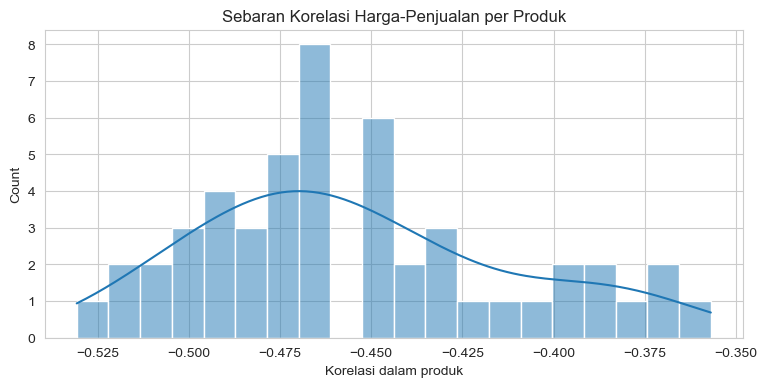

In [45]:
# korelasi harga-penjualan DI DALAM tiap produk
elastisitas = (df.groupby('item_id')
                 .apply(lambda g: g['price'].corr(g['sales']))
                 .dropna()
                 .sort_values())

print('Rata-rata korelasi harga-penjualan per produk:', round(elastisitas.mean(), 3))
print('\nProduk paling sensitif harga:')
print(elastisitas.head(5))

plt.figure(figsize=(9, 4))
sns.histplot(elastisitas, bins=20, kde=True)
plt.title('Sebaran Korelasi Harga-Penjualan per Produk')
plt.xlabel('Korelasi dalam produk')
plt.show()

**Insight:** bila korelasi agregat mendekati nol namun per-produk konsisten negatif, harga tetap berpengaruh — hanya tersamarkan saat semua produk digabung.

### 8.4 Pola Penjualan Berdasarkan Waktu (Pertanyaan 4)

**Tujuan:** mendeteksi pola musiman (bulanan), pola mingguan, dan pertumbuhan antar tahun sebagai dasar perencanaan promo/stok.

In [46]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_name'] = df['date'].dt.day_name()

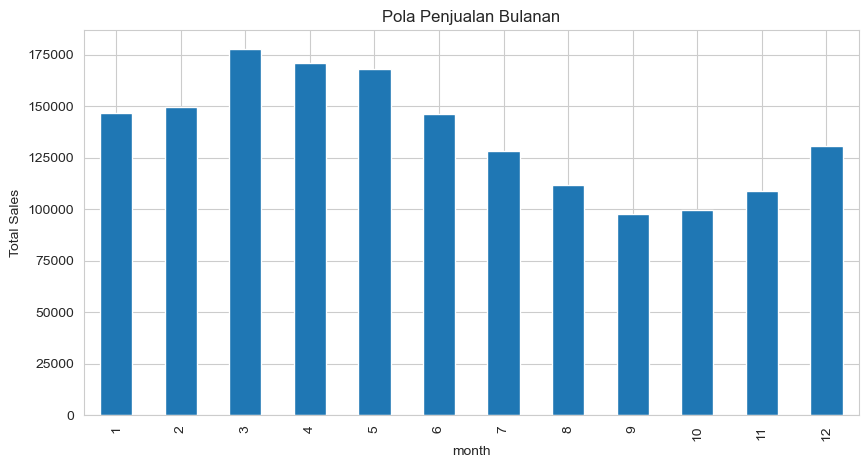

In [47]:
monthly_sales = df.groupby('month')['sales'].sum()

plt.figure(figsize=(10, 5))
monthly_sales.plot(kind='bar')
plt.title('Pola Penjualan Bulanan')
plt.ylabel('Total Sales')
plt.show()

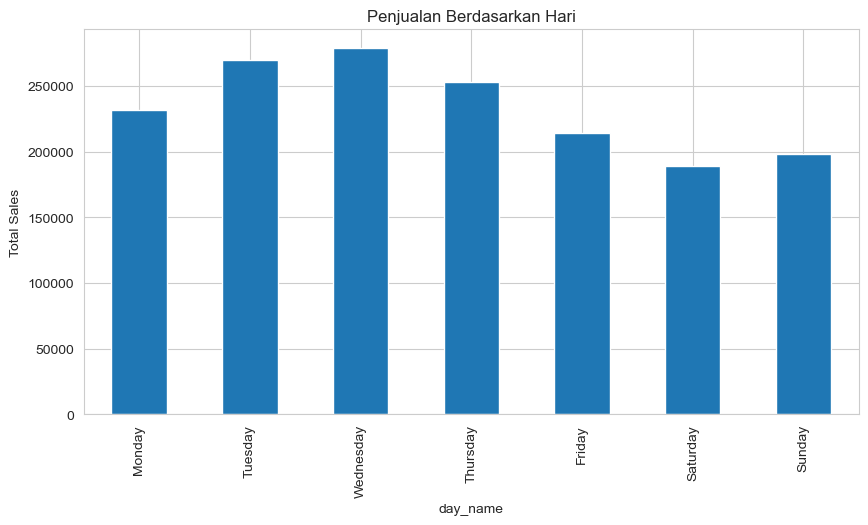

In [48]:
urutan = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_sales = df.groupby('day_name')['sales'].sum().reindex(urutan)

plt.figure(figsize=(10, 5))
weekday_sales.plot(kind='bar')
plt.title('Penjualan Berdasarkan Hari')
plt.ylabel('Total Sales')
plt.show()

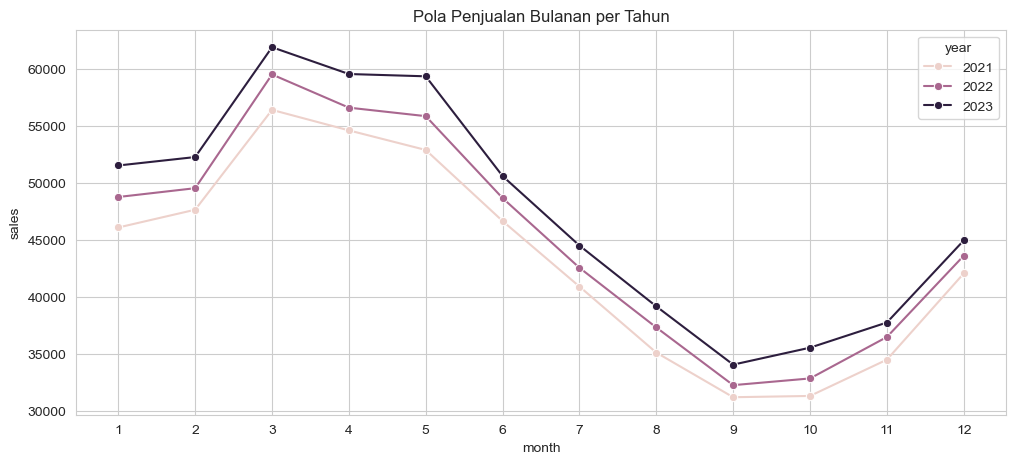

In [49]:
yoy = df.groupby(['year', 'month'])['sales'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=yoy, x='month', y='sales', hue='year', marker='o')
plt.title('Pola Penjualan Bulanan per Tahun')
plt.xticks(range(1, 13))
plt.show()

**Insight:** mengidentifikasi bulan/hari penjualan puncak dan konsistensi pola musiman antar tahun.

### 8.5 Variabel dengan Korelasi Terkuat terhadap Penjualan (Pertanyaan 5)

**Tujuan:** menentukan variabel yang paling berpengaruh terhadap penjualan sebagai prioritas feature engineering. Hanya variabel prediktor yang relevan yang diperiksa.

In [50]:
# periksa korelasi sales terhadap prediktor yang relevan
pred_cols = [c for c in ['price', 'promo', 'month', 'year', 'sales'] if c in df.columns]
corr_sales = df[pred_cols].corr()['sales'].drop('sales').sort_values(ascending=False)
print(corr_sales)

promo    0.293976
year     0.078912
price   -0.029426
month   -0.311165
Name: sales, dtype: float64


**Insight:** variabel dengan korelasi tertinggi (mis. promo) menjadi kandidat fitur utama; yang mendekati nol kurang informatif bila berdiri sendiri.

### 8.6 Deteksi Outlier Penjualan dan Penyebabnya (Pertanyaan 6)

**Tujuan:** memahami **penyebab** outlier, bukan hanya menghitungnya. Dicek apakah outlier sebenarnya hari promo atau produk laris (data valid) sebelum memutuskan buang/pertahankan.

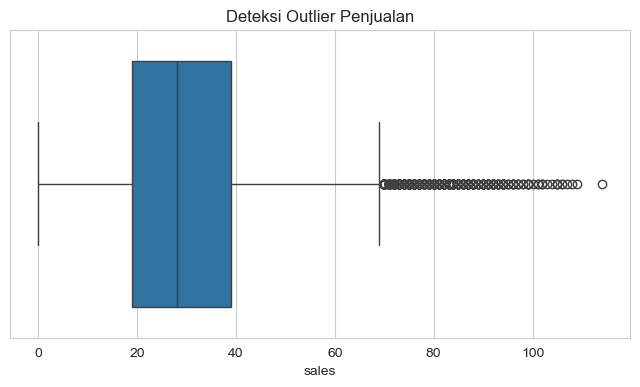

Jumlah outlier: 653


In [51]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['sales'])
plt.title('Deteksi Outlier Penjualan')
plt.show()

Q1, Q3 = df['sales'].quantile(0.25), df['sales'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outlier = df[(df['sales'] < lower) | (df['sales'] > upper)]
print('Jumlah outlier:', len(outlier))

In [52]:
if 'promo' in df.columns:
    print('Outlier saat promo :', f"{outlier['promo'].mean()*100:.1f}%")
    print('Promo seluruh data :', f"{df['promo'].mean()*100:.1f}%")

print('\nProduk penyumbang outlier terbanyak:')
print(outlier['item_id'].value_counts().head(5))

Outlier saat promo : 89.6%
Promo seluruh data : 9.9%

Produk penyumbang outlier terbanyak:
item_id
item_6     67
item_20    65
item_1     59
item_3     52
item_4     40
Name: count, dtype: int64


**Insight:** bila outlier didominasi hari promo/produk laris, lonjakan tersebut wajar dan sebaiknya dipertahankan, bukan dihapus.

# 9. Analisis Efektivitas Promo

**Tujuan:** mengukur dampak promo secara kuantitatif (berapa persen kenaikan penjualan), sehingga hasilnya langsung menjadi bahan keputusan bisnis.

            mean  median  count
promo                          
0      28.444634    27.0  49317
1      42.887907    41.0   5433

Kenaikan rata-rata penjualan saat promo: 50.8%


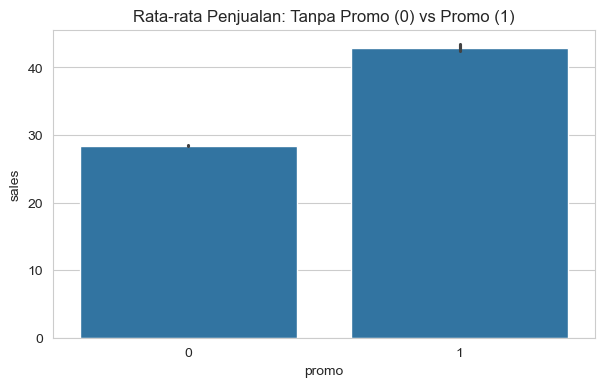

In [53]:
if 'promo' in df.columns:
    promo_effect = df.groupby('promo')['sales'].agg(['mean', 'median', 'count'])
    print(promo_effect)

    uplift = (df[df['promo']==1]['sales'].mean() /
              df[df['promo']==0]['sales'].mean() - 1) * 100
    print(f'\nKenaikan rata-rata penjualan saat promo: {uplift:.1f}%')

    plt.figure(figsize=(7, 4))
    sns.barplot(data=df, x='promo', y='sales')
    plt.title('Rata-rata Penjualan: Tanpa Promo (0) vs Promo (1)')
    plt.show()

# 10. Analisis ABC / Pareto

**Tujuan:** menjawab apakah sebagian kecil produk menyumbang sebagian besar penjualan (prinsip 80/20), untuk memfokuskan pengelolaan stok pada produk paling berdampak.

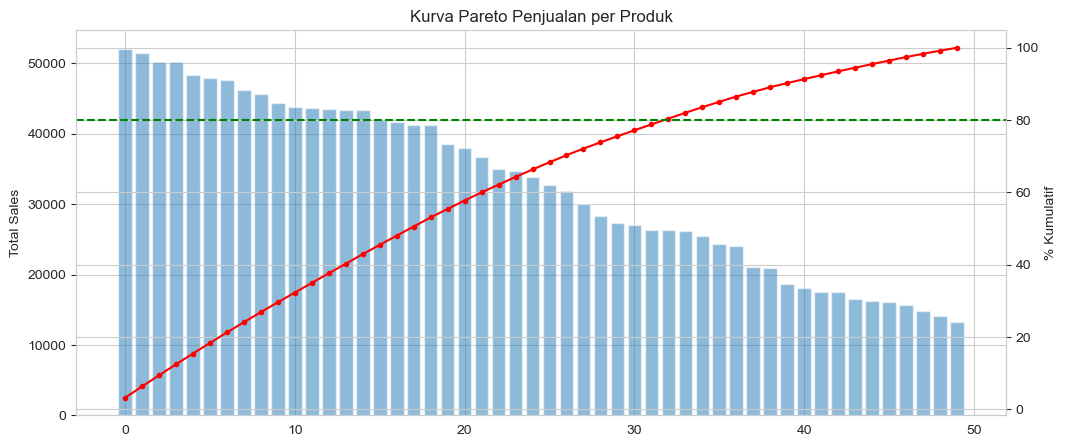

33 produk (66% katalog) menyumbang 80% penjualan


In [54]:
rev = df.groupby('item_id')['sales'].sum().sort_values(ascending=False)
kumulatif = rev.cumsum() / rev.sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(range(len(rev)), rev.values, alpha=0.5)
ax1.set_ylabel('Total Sales')
ax2 = ax1.twinx()
ax2.plot(range(len(rev)), kumulatif.values, color='red', marker='.')
ax2.axhline(80, color='green', linestyle='--')
ax2.set_ylabel('% Kumulatif')
plt.title('Kurva Pareto Penjualan per Produk')
plt.show()

n_80 = int((kumulatif <= 80).sum()) + 1
print(f'{n_80} produk ({n_80/len(rev)*100:.0f}% katalog) menyumbang 80% penjualan')

# 11. Uji Normalitas

**Tujuan:** menguji apakah variabel ukuran berdistribusi normal (Shapiro-Wilk) untuk menentukan metode statistik/scaling. Hanya `price` dan `sales` yang diuji — uji normalitas pada flag biner (`promo`) tidak bermakna.

In [55]:
for col in ['price', 'sales']:
    sample = df[col].dropna().sample(min(500, df[col].dropna().shape[0]), random_state=42)
    stat, p = shapiro(sample)
    status = 'Normal' if p > 0.05 else 'Tidak normal'
    print(f'{col:8s} p-value={p:.4f}  -> {status}')

price    p-value=0.0000  -> Tidak normal
sales    p-value=0.0000  -> Tidak normal


# 12. Kesimpulan EDA

Berdasarkan EDA, dataset memiliki karakteristik berikut sebagai dasar preprocessing & modeling:

- terdapat fitur dengan distribusi **skewed** (kandidat transformasi log),
- ditemukan **outlier** pada penjualan yang sebagian besar berkaitan dengan promo,
- **promo** merupakan pendorong penjualan terkuat,
- pengaruh **harga** tersamar pada level agregat namun terlihat per produk,
- penjualan terkonsentrasi pada sebagian produk (Pareto) dan memiliki **pola musiman**.

Temuan ini menjadi dasar feature engineering dan pemilihan model pada tahap berikutnya.